# Plotting photon and neutron energy spectra in a cell with a energy group structure

This example creates a simple sphere of tungsten with a neutron source inside.

Neutrons generate photons as they travel through the material.

Photon transport is enabled so these photons can be tracked tallied and plotted

Photon flux is averaged across the cell and plotted as a function of energy.

First import OpenMC and configure the nuclear data path

In [1]:
import matplotlib.pyplot as plt
import openmc
from pathlib import Path
# Setting the cross section path to the correct location in the docker image.
# If you are running this outside the docker image you will have to change this path to your local cross section path.
openmc.config['cross_sections'] = Path.home() / 'nuclear_data' / 'cross_sections.xml'

This section creates a simple material, geometry and settings. This model is used in both the photon current tally and photon flux tally.

In [2]:
# MATERIALS

# Tungsten is a very good photon shield, partly due to its high Z number and electrons
my_material = openmc.Material()
my_material.add_element('W', 1, percent_type='ao')
my_material.set_density('g/cm3', 19)

my_materials = openmc.Materials([my_material])

# GEOMETRY

# surfaces
outer_surface = openmc.Sphere(r=100, boundary_type='vacuum')

# cells
blanket_cell = openmc.Cell(region=-outer_surface)
blanket_cell.fill = my_material

my_geometry = openmc.Geometry([blanket_cell])


# SIMULATION SETTINGS

# Instantiate a Settings object
my_settings = openmc.Settings()
my_settings.batches = 10
my_settings.particles = 1000
my_settings.run_mode = 'fixed source'
my_settings.photon_transport = True  # This line is required to switch on photons tracking, other wise the photons created by the neutrons are not tracked


# Create a DT point source
source = openmc.IndependentSource()
source.space = openmc.stats.Point((0, 0, 0))
source.angle = openmc.stats.Isotropic()
# neutron is the default source.particle value so this line is not actually necessary for the simulation.
# However it is added for clarity.
# This simulation has a neutron source and those neutrons generate photons via interactions with the material.
# The resulting photons energy spectrum is tallied, but the units are still per source netron.
source.particle = 'neutron' 
source.energy = openmc.stats.Discrete([14e6], [1])
my_settings.source = source

This section section adds a tally for the average photon flux across a cell.

In [3]:
#creates an empty tally object
my_tallies = openmc.Tallies()

# sets up filters for the tallies
particle_filter = openmc.ParticleFilter(['photon'])  # note the use of photons here, otherwise all particles are tallied
energy_filter = openmc.EnergyFilter.from_group_structure('VITAMIN-J-175')

# setup the filters for the cell tally
cell_filter = openmc.CellFilter(blanket_cell) 

# create the tally
cell_spectra_tally = openmc.Tally(name='cell_photon_spectra_tally')
cell_spectra_tally.scores = ['flux']
cell_spectra_tally.filters = [cell_filter, particle_filter, energy_filter]
my_tallies.append(cell_spectra_tally)

This section runs the simulation.

In [4]:
# combine all the required parts to make a model
model = openmc.model.Model(my_geometry, my_materials, my_settings, my_tallies)

# remove old files and runs OpenMC
!rm *.h5 || true
results_filename = model.run()

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

 Reading W183 from /home/jon/nuclear_data/neutron/W183.h5


 Reading W184 from /home/jon/nuclear_data/neutron/W184.h5
 Reading W186 from /home/jon/nuclear_data/neutron/W186.h5


 Minimum neutron data temperature: 294.0 K
 Maximum neutron data temperature: 294.0 K
 Preparing distributed cell instances...
 Writing summary.h5 file...
 Maximum neutron transport energy: 150000000.0 eV for W180

 ===============>     FIXED SOURCE TRANSPORT SIMULATION     <===============

 Simulating batch 1


 Simulating batch 2


 Simulating batch 3
 Simulating batch 4


 Simulating batch 5
 Simulating batch 6


 Simulating batch 7
 Simulating batch 8


 Simulating batch 9
 Simulating batch 10


 Creating state point statepoint.10.h5...

 =======================>     TIMING STATISTICS     <=======================

 Total time for initialization     = 1.0550e+00 seconds
   Reading cross sections          = 1.0305e+00 seconds
 Total time in simulation          = 1.6649e+00 seconds
   Time in transport only          = 1.5801e+00 seconds
   Time in active batches          = 1.6649e+00 seconds
   Time accumulating tallies       = 6.3577e-02 seconds
   Time writing statepoints        = 1.8554e-02 seconds
 Total time for finalization       = 1.3080e-03 seconds
 Total time elapsed                = 2.7281e+00 seconds
 Calculation Rate (active)         = 6006.43 particles/second

 ============================>     RESULTS     <============================

 Leakage Fraction            = 0.00020 +/- 0.00013



This section extracts the cell tally data from the results file and plots photon flux across the cell.

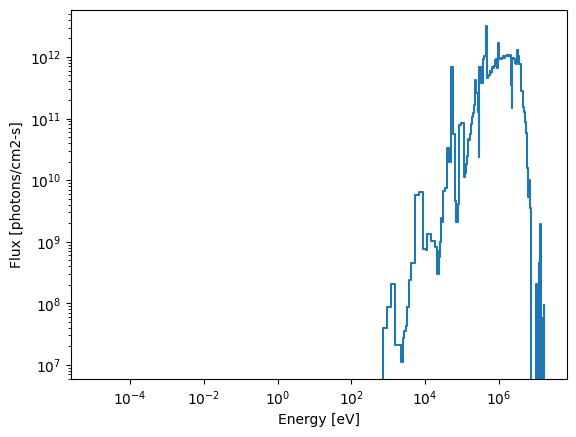

In [5]:
# open the results file
results = openmc.StatePoint(results_filename)

#extracts the tally values from the simulation results
cell_tally = results.get_tally(name='cell_photon_spectra_tally')

# flattens the ndarray into a 1d array for plotting
openmc_flux = cell_tally.mean.flatten()

volume_of_cell = 4188790 # cell is 100cm radius sphere, this volume is in units of cm3
reactor_power = 500e6  # in units of watts
energy_of_each_fusion_reaction = 17.5e6 * 2.8e-18  # eV converted to Joules
neutrons_per_second = reactor_power / energy_of_each_fusion_reaction

flux = (openmc_flux / volume_of_cell) * neutrons_per_second # divide by cell volume and then multiply by source strength


plt.figure()
 # trim the last energy filter bin edge to make the number of x and y values the same
plt.step(energy_filter.values[:-1], flux)
plt.yscale('log')
plt.xscale('log')
plt.ylabel('Flux [photons/cm2-s]')
plt.xlabel('Energy [eV]')
plt.show()

- In this simulation we used the VITAMIN-J-175 energy group structure to tally photons in energy bins.
- There are several group structures built into OpenMC.
- The VITAMIN-J-175, CCFE-709 and UKAEA-1102 structures are popular in fusion energy as they include 14MeV in the range.
- OpenMC source code with other group structures can be found here: https://github.com/openmc-dev/openmc/blob/develop/openmc/mgxs/__init__.py.

**Learning Outcomes for Part 2:**

- OpenMC can perform coupled neutron-photon simulations where photons are created from neutron interactions.
- Photon spectra can be tallied in OpenMC using flux or current tallies, and energy bins.